In [3]:
# 랭그래프의 이해
!pip install langgraph
!pip install pydantic

{'text': 'hello world!!!'}


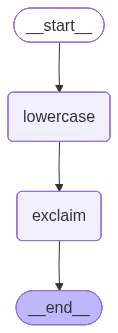

In [6]:
from langgraph import graph
from typing import TypedDict
from langgraph.graph import StateGraph, END, START    # StateGraph API 뜯어볼 필요 있다.
from pydantic import BaseModel, Field

# State 정의 : 그래프에서 이동하는 데이터의 구조를 정의, 랭그래프는 모든 데이터가 State(상태)로 이동.

class MyState(TypedDict):
  text:str    # 멤버 필드명:타입

class MyState2(BaseModel):
  text:str = Field(default="",description="문자열")
  # ...

# Node 정의 : 각 노드는 State를 받아 State를 반환
def node_lowerCase(state:MyState):    # 메세지를 소문자화
  new_text = state["text"].lower()
  return {"text":new_text}

def node_exclaim(state:MyState):     # 메세지 뒤에 느낌표 추가
  new_text = state["text"] + "!!!"
  return {"text":new_text}


# 그래프 구성. 노드들을 그래프로 이어붙여 실행 흐름을 생성
def build_graph():
  graph = StateGraph(MyState)

  # 노드 추가
  graph.add_node("lowercase",node_lowerCase)
  graph.add_node("exclaim",node_exclaim)


  # 진입점 : 프로그램이 실행될 때 가장 먼저 수행될 노드 지정
  graph.set_entry_point("lowercase")

  # 흐름 연결
  # graph.add_edge(START, "lowercase")    # 생략 가능
  graph.add_edge("lowercase","exclaim")
  graph.add_edge("exclaim",END)

  # 컴파일
  return graph.compile()    # 설계도를 컴파일(실행 가능한 그래프 엔진으로 변환:Runnable Graph)한 후 반환


  # ------------------ 위쪽이 설계 / 아래 쪽이 실행 ---------------------
if __name__=="__main__":
  graph = build_graph()
  print(graph.invoke({"text":"HELLO WORLD"}))

  # 그래프 시각화 : Jupyter 기준 (vscode에서 display 못씀. image로 저장해서 plt로 불러와야함)
  from IPython.display import Image, display
  graph_obj = graph.get_graph()
  png_bytes = graph_obj.draw_mermaid_png()     # Mermaid 기반 png 이미지 얻기
  display(Image(png_bytes))

# LangChain Agent : LLM 중심(흐름을 LLM이 결정), Tool 호출, 추론 기반 routing ...
# LangGraph Agent : Node, State 기반. Workflow 제어가 명확하다(흐름 개발자가 결정) - Multi Agent 협업 가능